In [1]:
import pandas as pd
import numpy as np
import seaborn as sns  
import matplotlib.pyplot as plt  

In [2]:
df = pd.read_csv("/Users/tomchege/Documents/machine_learning_assignment/data/job_salary_prediction_dataset.csv")
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB
None


In [4]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [5]:
# ======================================================
# STEP 1: LOAD & INITIAL INSPECTION
# ======================================================

print("-" * 40)
print("DATA LOADED")
print("-" * 40)
print(f"Shape:              {df.shape} rows, {df.shape} columns")
print(f"Columns:            {list(df.columns)}")
print("-" * 40)

# ======================================================
# STEP 2: MISSING VALUE REPORT
# ======================================================

print("\n" + "-" * 40)
print("MISSING VALUE REPORT")
print("-" * 40)
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df) * 100).round(2)

# Create a DataFrame to align columns nicely
missing_df = pd.DataFrame({
    'Column': missing_counts.index,
    'Count': missing_counts.values,
    'Pct (%)': missing_pct.values
})

# Format output as a clean table
print(f"{'Column':<20} {'Count':>10} {'Pct (%)':>10}")
print("-" * 40)
for _, row in missing_df.iterrows():
    print(f"{row['Column']:<20} {row['Count']:>10} {row['Pct (%)']:>10.2f}")
print("-" * 40)

# ======================================================
# STEP 3: DATA QUALITY CHECKS
# ======================================================

print("\n" + "-" * 40)
print("DATA QUALITY CHECKS")
print("-" * 40)

# Duplicates
dups = df.duplicated().sum()
print(f"Duplicate Rows:     {dups}")

# Constant Columns
const_cols = df.columns[df.nunique() == 1]
print(f"Constant Columns:   {len(const_cols)} found")
if len(const_cols) > 0:
    print(f"  - {', '.join(const_cols)}")

# ======================================================
# STEP 4: STRING CLEANING REPORT
# ======================================================

print("\n" + "-" * 40)
print("STRING CLEANING REPORT")
print("-" * 40)
print("Action: Stripping whitespace from all text columns...")
df = df.apply(lambda x: x.str.strip() if x.dtype == 'object' else x)
print("Result: Whitespace removed from all string columns.")
print("-" * 40)

# ======================================================
# STEP 5: MISSING VALUE HANDLING REPORT
# ======================================================

print("\n" + "-" * 40)
print("MISSING VALUE HANDLING")
print("-" * 40)

# Identify columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

print(f"Numeric Columns:    {len(numeric_cols)}")
print(f"Categorical Cols:   {len(cat_cols)}")
print("-" * 40)

# Fill Numeric
filled_numeric = 0
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())
        filled_numeric += 1

# Fill Categorical
filled_cat = 0
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna('Unknown')
        filled_cat += 1

print(f"Numeric Filled:     {filled_numeric} columns (Median)")
print(f"Categorical Filled: {filled_cat} columns ('Unknown')")
print("-" * 40)

# ======================================================
# STEP 6: DUPLICATE REMOVAL REPORT
# ======================================================

# print("\n" + "-" * 40)
# print("DUPLICATE REMOVAL")
# print("-" * 40)
# old_len = df.shape
# df = df.drop_duplicates()
# new_len = df.shape
# removed = old_len - new_len

# print(f"Removed:            {removed} duplicate rows")
# print(f"New Shape:          {df.shape} rows, {df.shape} columns")
# print("-" * 40)

# ======================================================
# STEP 7: OUTLIER DETECTION REPORT (Per Column)
# ======================================================

print("\n" + "-" * 40)
print("OUTLIER DETECTION REPORT (IQR Method)")
print("-" * 40)

# Only run on numeric columns
outlier_details = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers_count = ((df[col] < lower) | (df[col] > upper)).sum()
    
    # Format the report for this column
    print(f"\nColumn: {col}")
    print(f"Q1 (25th):      {Q1:12.2f}")
    print(f"Q3 (75th):      {Q3:12.2f}")
    print(f"IQR:            {IQR:12.2f}")
    print(f"Lower Bound:    {lower:12.2f}")
    print(f"Upper Bound:    {upper:12.2f}")
    print(f"Outliers Found: {outliers_count}")
    print("-" * 40)

# total_outliers = sum(((df[col] < (df[col].quantile(0.25) - 1.5 * (df[col].quantile(0.75) - df[col].quantile(0.25))) | 
#                        (df[col] > (df[col].quantile(0.75) + 1.5 * (df[col].quantile(0.75) - df[col].quantile(0.25))))) 
#                       for col in numeric_cols))

# print(f"\nTOTAL OUTLIERS FOUND: {total_outliers}")
print("-" * 40)

# ======================================================
# STEP 8: MEMORY OPTIMIZATION REPORT
# ======================================================

print("\n" + "-" * 40)
print("MEMORY OPTIMIZATION REPORT")
print("-" * 40)

original_size = df.memory_usage(deep=True).sum() / 1024**2  # MB

# Convert low-cardinality text to category
for col in df.columns:
    if df[col].dtype == 'object':
        if df[col].nunique() / len(df) < 0.5:
            df[col] = df[col].astype('category')

optimized_size = df.memory_usage(deep=True).sum() / 1024**2 # MB
saved_mb = original_size - optimized_size

print(f"Original Size:    {original_size:.2f} MB")
print(f"Optimized Size:   {optimized_size:.2f} MB")
print(f"Space Saved:      {saved_mb:.2f} MB ({saved_mb/original_size*100:.1f}%)")
print("-" * 40)

# ======================================================
# STEP 9: FINAL VERIFICATION
# ======================================================

print("\n" + "=" * 40)
print("CLEANING COMPLETE")
print("=" * 40)
print(f"Final Shape:      {df.shape} rows, {df.shape} columns")
print(f"Final Memory:     {optimized_size:.2f} MB")
print(f"Status:           Ready for Analysis")
print("=" * 40)

----------------------------------------
DATA LOADED
----------------------------------------
Shape:              (250000, 10) rows, (250000, 10) columns
Columns:            ['job_title', 'experience_years', 'education_level', 'skills_count', 'industry', 'company_size', 'location', 'remote_work', 'certifications', 'salary']
----------------------------------------

----------------------------------------
MISSING VALUE REPORT
----------------------------------------
Column                    Count    Pct (%)
----------------------------------------
job_title                     0       0.00
experience_years              0       0.00
education_level               0       0.00
skills_count                  0       0.00
industry                      0       0.00
company_size                  0       0.00
location                      0       0.00
remote_work                   0       0.00
certifications                0       0.00
salary                        0       0.00
---------------

In [6]:
# 1. Calculate Q1, Q3, and IQR
Q1 = df['salary'].quantile(0.25)
Q3 = df['salary'].quantile(0.75)
IQR = Q3 - Q1

# 2. Define the outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Identify outliers
outliers = df[(df['salary'] < lower_bound) | (df['salary'] > upper_bound)]

# 4. Central Tendencies
max_salary = df["salary"].max()
min_salary = df["salary"].min()

median_salary = df["salary"].median()  
mean_salary = df["salary"].mean()
mode_salary = df["salary"].mode()

# 5. Display results
print("-" * 50)
print("OUTLIER DETECTION REPORT: SALARY")
print("-" * 50)
print(f"Column: {'salary'}")
print(f"Q1 (25th percentile):      ${Q1:>12,.2f}")
print(f"Q3 (75th percentile):      ${Q3:>12,.2f}")
print(f"IQR:                       ${IQR:>12,.2f}")
print(f"Lower Bound:               ${lower_bound:>12,.2f}")
print(f"Upper Bound:               ${upper_bound:>12,.2f}")
print("-" * 50)
print(f"Number of outliers found:  {len(outliers)}")
print("-" * 50)
print('')
print("Central Tendency")
print("-" * 50)
print(f"Largest Salary:            ${max_salary:>12,.2f}")
print(f"Smallest Salary:           ${min_salary:>12,.2f}")
print(f"Median:                    ${median_salary:>12,.2f}")
print(f"Mean:                      ${mean_salary:>12,.2f}") 

print('')
print("-" * 50)
print("Distribution")
print("-" * 50)

# Calculate the difference percentage to be precise
diff_percent = abs(mean_salary - median_salary) / median_salary * 100

print(f"Mean:   ${mean_salary:>12,.2f}")
print(f"Median: ${median_salary:>12,.2f}")
print(f"Difference: {diff_percent:.4f}%")
print("-" * 50)

if abs(mean_salary - median_salary) < (median_salary * 0.05): # Less than 5% difference
    print("RESULT: SYMMETRIC (NORMAL) DISTRIBUTION")
    print("  - The Mean and Median are nearly identical.")
    print("  - The data is likely balanced around the center.")
    print("  - No significant skewness detected.")
elif mean_salary > median_salary:
    print("RESULT: RIGHT SKEWED (POSITIVE SKEW)")
    print("  - The Mean is pulled higher by a few large salaries.")
    print("  - The 'tail' extends to the right.")
else:
    print("RESULT: LEFT SKEWED (NEGATIVE SKEW)")
    print("  - The Mean is pulled lower by a few small salaries.")
    print("  - The 'tail' extends to the left.")

print("-" * 50)

--------------------------------------------------
OUTLIER DETECTION REPORT: SALARY
--------------------------------------------------
Column: salary
Q1 (25th percentile):      $  119,358.00
Q3 (75th percentile):      $  169,492.00
IQR:                       $   50,134.00
Lower Bound:               $   44,157.00
Upper Bound:               $  244,693.00
--------------------------------------------------
Number of outliers found:  2336
--------------------------------------------------

Central Tendency
--------------------------------------------------
Largest Salary:            $  333,046.00
Smallest Salary:           $   31,867.00
Median:                    $  143,453.00
Mean:                      $  145,718.08

--------------------------------------------------
Distribution
--------------------------------------------------
Mean:   $  145,718.08
Median: $  143,453.00
Difference: 1.5790%
--------------------------------------------------
RESULT: SYMMETRIC (NORMAL) DISTRIBUTION
  - The

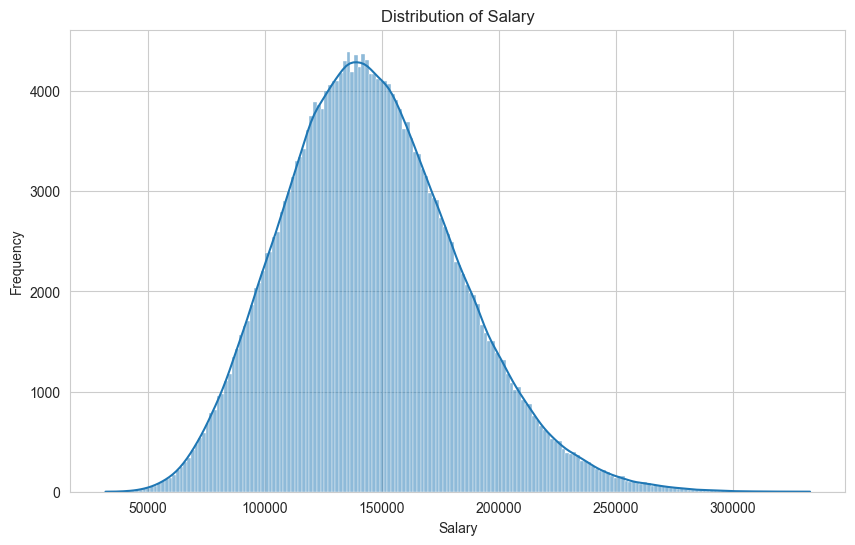

In [7]:
# Distribution of Salary (Target Variable)
plt.figure()
sns.histplot(df['salary'], kde=True)
plt.title('Distribution of Salary')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.show()

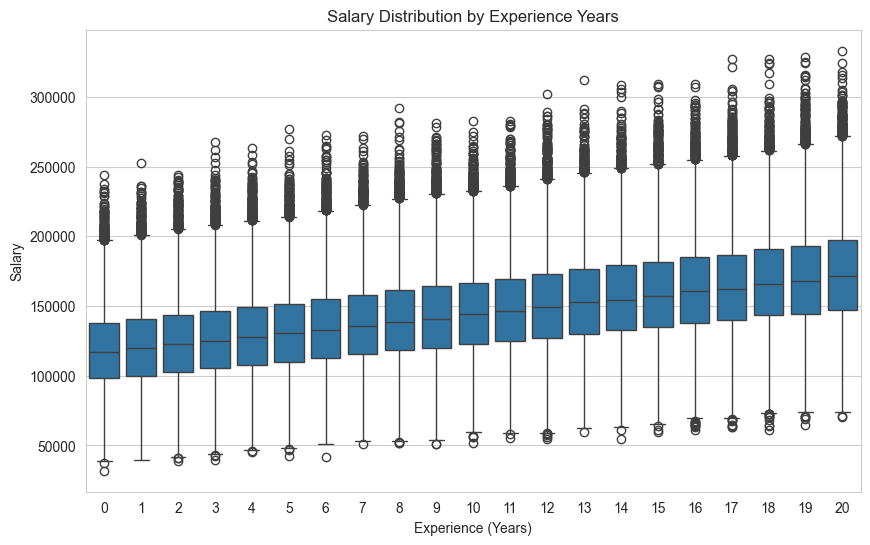

In [8]:
# Salary by Experience Years
plt.figure()
sns.boxplot(x='experience_years', y='salary', data=df)
plt.title('Salary Distribution by Experience Years')
plt.xlabel('Experience (Years)')
plt.ylabel('Salary')
plt.show()

In [9]:
# Calculate average salary by experience years
avg_salary_by_exp = df.groupby('experience_years')['salary'].mean().sort_index()

# Display as a clean table
print("\n" + "=" * 50)
print(f"{'Experience (Years)':<20} | {'Avg Salary':>15}")
print("=" * 50)

for exp, salary in avg_salary_by_exp.items():
    print(f"{exp:<20} | ${salary:>14,.2f}")

print("=" * 50)


Experience (Years)   |      Avg Salary
0                    | $    118,872.62
1                    | $    121,250.53
2                    | $    124,228.94
3                    | $    126,921.60
4                    | $    129,688.78
5                    | $    131,787.25
6                    | $    134,898.30
7                    | $    137,560.81
8                    | $    140,667.76
9                    | $    142,763.83
10                   | $    145,771.97
11                   | $    148,133.17
12                   | $    150,779.03
13                   | $    154,082.62
14                   | $    156,413.15
15                   | $    158,981.14
16                   | $    162,290.87
17                   | $    164,282.18
18                   | $    167,421.19
19                   | $    169,797.36
20                   | $    173,179.71


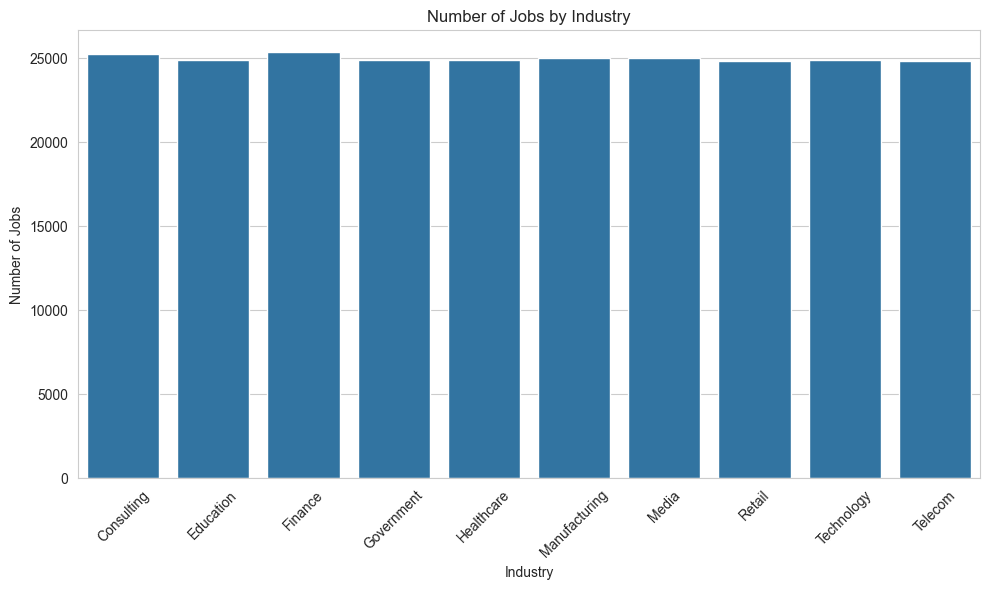

In [10]:
# Count of Jobs by Industry
plt.figure()
industry_counts = df['industry'].value_counts()
sns.barplot(x=industry_counts.index, y=industry_counts.values)
plt.title('Number of Jobs by Industry')
plt.xlabel('Industry')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [11]:
# Calculate average salary by industry
avg_salary_by_industry = df.groupby('industry')['salary'].mean().sort_values(ascending=False)

# Calculate job counts for context
job_counts = df['industry'].value_counts()

# Display as a clean table
print("\n" + "=" * 70)
print(f"{'Industry':<30} | {'Avg Salary':>15} | {'Job Count':>10}")
print("=" * 70)

for industry in avg_salary_by_industry.index:
    avg_sal = avg_salary_by_industry[industry]
    count = job_counts[industry]
    print(f"{industry:<30} | ${avg_sal:>14,.2f} | {count:>10,}")

print("=" * 70)


Industry                       |      Avg Salary |  Job Count
Education                      | $    145,993.56 |     24,889
Media                          | $    145,891.27 |     25,034
Telecom                        | $    145,876.51 |     24,859
Technology                     | $    145,863.81 |     24,903
Finance                        | $    145,801.64 |     25,393
Healthcare                     | $    145,760.00 |     24,898
Government                     | $    145,613.87 |     24,901
Manufacturing                  | $    145,530.60 |     25,024
Consulting                     | $    145,451.64 |     25,258
Retail                         | $    145,399.70 |     24,841


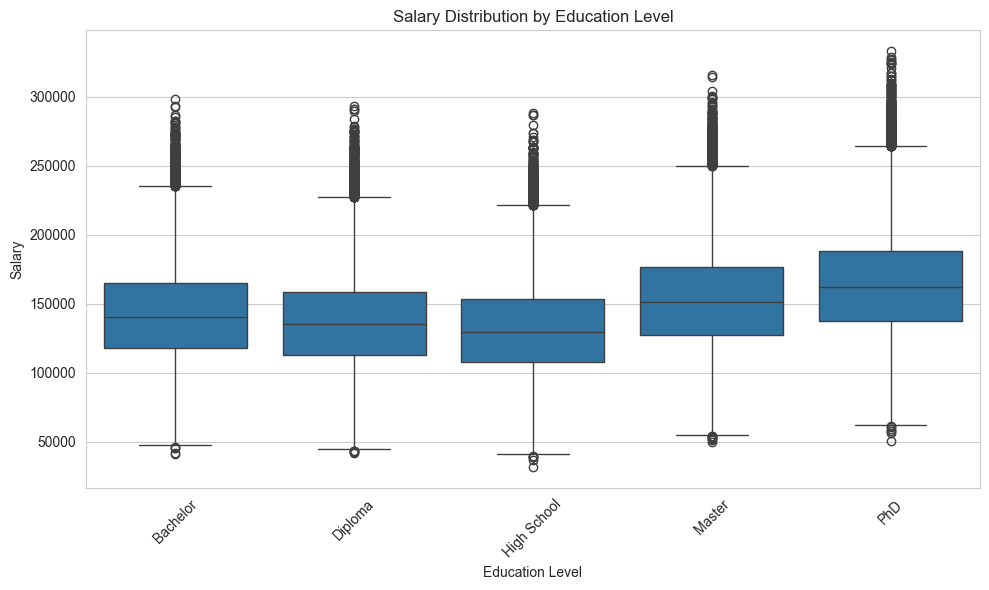

In [12]:
# Salary by Education Level
plt.figure()
sns.boxplot(x='education_level', y='salary', data=df)
plt.title('Salary Distribution by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Salary')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
# Calculate average salary by education level
avg_salary_by_edu = df.groupby('education_level')['salary'].mean().sort_values(ascending=False)

# Display as a clean table
print("\n" + "=" * 60)
print(f"{'Education Level':<25} | {'Average Salary':>15}")
print("=" * 60)
for edu, salary in avg_salary_by_edu.items():
    print(f"{edu:<25} | ${salary:>14,.2f}")
print("=" * 60)


Education Level           |  Average Salary
PhD                       | $    163,976.01
Master                    | $    153,305.31
Bachelor                  | $    142,410.53
Diploma                   | $    137,158.57
High School               | $    131,715.34


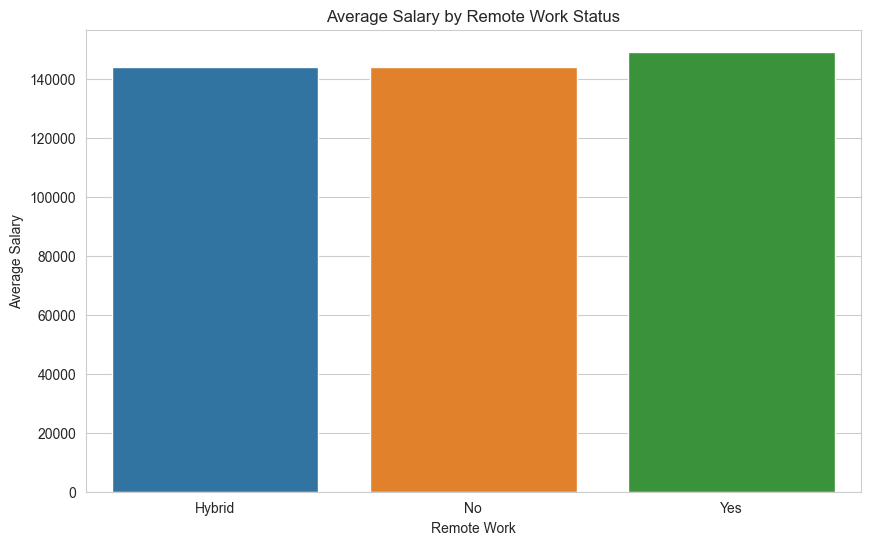

In [14]:
# Remote Work Impact on Salary
plt.figure()
remote_salary_avg = df.groupby('remote_work')['salary'].mean().sort_values(ascending=False)
sns.barplot(x=remote_salary_avg.index, y=remote_salary_avg.values, hue=remote_salary_avg.index, legend=False)
plt.title('Average Salary by Remote Work Status')
plt.xlabel('Remote Work')
plt.ylabel('Average Salary')
plt.show()

In [16]:
from scipy.stats import f_oneway

# Why ANOVA instead of T-Test?

# T-Test: Like comparing two teams in a race to see who is faster.
# ANOVA: Like comparing three or more teams. It asks, "Is there any difference among these groups?"
# The "F-Statistic": In ANOVA, we look at the F-statistic (not T-statistic). 
# It measures the ratio of variance between groups to variance within groups. A high F-value suggests the groups are different.

# Define Hypotheses
H0 = "There is no significant difference in average salary between remote, hybrid, and on-site workers."
H1 = "There is a significant difference in average salary between at least one of the groups."

alpha = 0.05

# Extract groups
remote_group = df[df['remote_work'] == 'Yes'] ['salary']
onsite_group = df[df['remote_work'] == 'No'] ['salary']
hybrid_group = df[df['remote_work'] == 'Hybrid'] ['salary']

# Check for empty groups to avoid errors
if remote_group.empty or onsite_group.empty or hybrid_group.empty:
    print("Error: One or more groups have no data. Cannot perform ANOVA.")
else:
    # Run One-Way ANOVA
    stat, p_value = f_oneway(remote_group, onsite_group, hybrid_group)

    # Output
    print("\n" + "=" * 70)
    print("TEST: REMOTE WORK IMPACT ON SALARY (ONE-WAY ANOVA)")
    print("=" * 70)

    print(f"Alpha: {alpha}")
    print("-" * 70)
    print(f"F-Statistic: {stat:.4f}")
    print(f"P-Value:     {p_value:.6f}")
    print("-" * 70)

    if p_value <= alpha:
        print(f"Result: Reject the null hypothesis ({H0})")
        print("        -> There is a statistically significant difference in salary.")
        print("        -> Note: ANOVA tells you groups differ, but not WHICH ones.")
    else:
        print(f"Result: Fail to reject the null hypothesis ({H0})")
        print("        -> No significant difference found between the groups.")
    
    print("=" * 70)


TEST: REMOTE WORK IMPACT ON SALARY (ONE-WAY ANOVA)
Alpha: 0.05
----------------------------------------------------------------------
F-Statistic: 564.7059
P-Value:     0.000000
----------------------------------------------------------------------
Result: Reject the null hypothesis (There is no significant difference in average salary between remote, hybrid, and on-site workers.)
        -> There is a statistically significant difference in salary.
        -> Note: ANOVA tells you groups differ, but not WHICH ones.


In [17]:
print(f"\n[H2] Education Level vs Average Salary")
edu_avg = df.groupby('education_level')['salary'].mean().sort_values(ascending=False)
print(f"    {'Education Level':<20} | {'Avg Salary':>15}")
print(f"    {'-'*20}+{'-'*15}")
for level, sal in edu_avg.items():
    print(f"    {level:<20} | ${sal:>14,.2f}")


[H2] Education Level vs Average Salary
    Education Level      |      Avg Salary
    --------------------+---------------
    PhD                  | $    163,976.01
    Master               | $    153,305.31
    Bachelor             | $    142,410.53
    Diploma              | $    137,158.57
    High School          | $    131,715.34


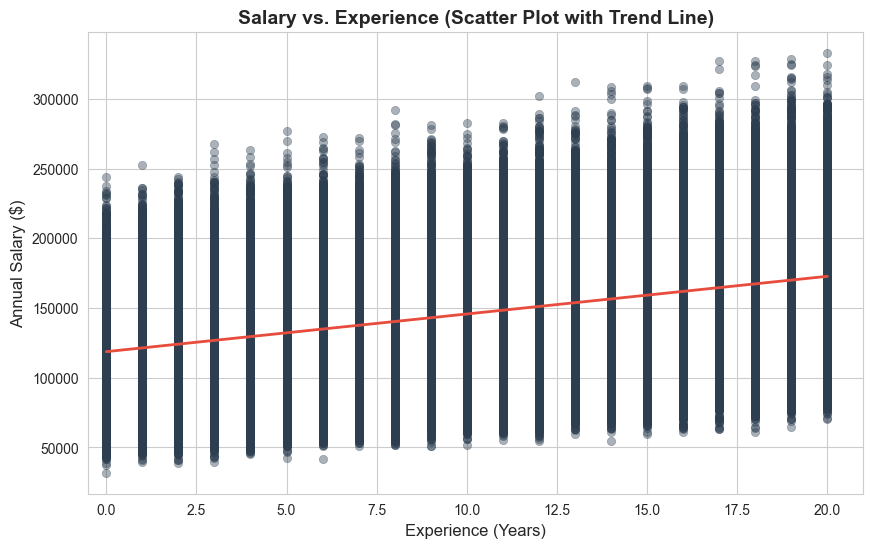


VISUAL ANALYSIS SUMMARY: EXPERIENCE VS SALARY
Correlation (r): 0.4376
P-Value:         0.000000
Interpretation: 
 There is a statistically significant MODERATE POSITIVE relationship.
For every 1 year of experience, salary increases by roughly:
 $2,701.17 per year.


In [18]:

from scipy.stats import pearsonr

# pearsonr typically refers to the Pearson correlation coefficient, a statistical measure that calculates the linear correlation between two sets of data. The value ranges from -1 to 1:

# 1: Perfect positive correlation
# 0: No linear correlation
# -1: Perfect negative correlation

# Create scatter plot with a slight transparency to handle overplotting
sns.scatterplot(
    x='experience_years', 
    y='salary', 
    data=df, 
    alpha=0.4,       
    color='#2c3e50', 
    edgecolor=None
)

# Add trend line
sns.regplot(
    x='experience_years', 
    y='salary', 
    data=df, 
    scatter=False,   # Don't draw points again
    color='#e74c3c', # Redish trend line for contrast
    line_kws={'linewidth': 2}
)

plt.title('Salary vs. Experience (Scatter Plot with Trend Line)', fontsize=14, fontweight='bold')
plt.xlabel('Experience (Years)', fontsize=12)
plt.ylabel('Annual Salary ($)', fontsize=12)
plt.xlim(-0.5, max(df['experience_years']) + 1) # Slight padding on x-axis


plt.show()

# --- 2. Text-Based Statistical Summary 
r_val, p_val = pearsonr(df['experience_years'], df['salary'])

print("\n" + "=" * 70)
print("VISUAL ANALYSIS SUMMARY: EXPERIENCE VS SALARY")
print("=" * 70)
print(f"Correlation (r): {r_val:.4f}")
print(f"P-Value:         {p_value:.6f}")

if p_val <= 0.05:
    strength = "STRONG" if abs(r_val) > 0.7 else "MODERATE" if abs(r_val) > 0.3 else "WEAK"
    direction = "POSITIVE" if r_val > 0 else "NEGATIVE"
    print(f"Interpretation: \n There is a statistically significant {strength} {direction} relationship.")
    print(f"For every 1 year of experience, salary increases by roughly:")
    
    # Calculate slope (approximate increase per year)
    slope = df['experience_years'].cov(df['salary']) / df['experience_years'].var()
    print(f" ${slope:,.2f} per year.")
else:
    print("Interpretation: No statistically significant linear relationship found.")

print("=" * 70)

In [19]:
from scipy.stats import pearsonr
# Define Hypotheses
H0 = "There is no significant correlation between experience years and salary."
H1 = "There is a significant correlation between experience years and salary."

alpha = 0.05

# Run Correlation Test
corr, p_value = pearsonr(df['experience_years'], df['salary'])

# Output
print("\n" + "=" * 70)
print("TEST: EXPERIENCE VS SALARY CORRELATION")
print("=" * 70)

print(f"Alpha: {alpha}")
print("-" * 70)
print(f"Correlation (r): {corr:.4f}")
print(f"P-Value:         {p_value:.6f}")
print("-" * 70)

if p_value <= alpha:
    print(f"Result: Reject the null hypothesis \n ({H0})")
    print(f"        -> Significant correlation exists (r = {corr:.2f}).")
else:
    print(f"Result: Fail to reject the null hypothesis ({H0})")
    print("        -> No significant correlation found.")
print("=" * 70)


TEST: EXPERIENCE VS SALARY CORRELATION
Alpha: 0.05
----------------------------------------------------------------------
Correlation (r): 0.4376
P-Value:         0.000000
----------------------------------------------------------------------
Result: Reject the null hypothesis 
 (There is no significant correlation between experience years and salary.)
        -> Significant correlation exists (r = 0.44).


In [20]:
# H4: Top 5 Industries by Salary
print(f"\n[H4] Top 5 Industries by Average Salary")
ind_avg = df.groupby('industry')['salary'].mean().sort_values(ascending=False).head(5)
for ind, sal in ind_avg.items():
    print(f"    {ind:<25} : ${sal:>12,.2f}")


[H4] Top 5 Industries by Average Salary
    Education                 : $  145,993.56
    Media                     : $  145,891.27
    Telecom                   : $  145,876.51
    Technology                : $  145,863.81
    Finance                   : $  145,801.64


In [21]:
# H5: Certifications vs Salary (Correlation)
print(f"\n Certifications vs Salary")
print("\n" + "=" * 80)
corr_cert = df['certifications'].corr(df['salary'])
print(f"    Correlation Coefficient: {corr_cert:.3f}")
if corr_cert > 0.3:
    print(f"    Status: MODERATE POSITIVE IMPACT (Hypothesis Supported)")
else:
    print(f"    Status: WEAK OR NO IMPACT")

print("\n" + "=" * 80)
print("END OF REPORT")
print("=" * 80)


 Certifications vs Salary

    Correlation Coefficient: 0.074
    Status: WEAK OR NO IMPACT

END OF REPORT


In [22]:
import pandas as pd
from scipy.stats import ttest_ind, f_oneway, pearsonr, mannwhitneyu, kruskal

print("=" * 70)
print("STATISTICAL TEST SELECTION GUIDE")
print("=" * 70)
print("Data Status: Normal Distribution (Mean ≈ Median)")
print("Recommended Approach: PARAMETRIC TESTS (Higher Power)")
print("=" * 70)

# 1. Independent T-Test: Remote vs. On-Site (Parametric)
print("\n[TEST 1] Remote Work Impact (Parametric: T-Test)")
remote_group = df[df['remote_work'] == 'Yes'] ['salary']
onsite_group = df[df['remote_work'] == 'No'] ['salary']
t_stat, p_val = ttest_ind(remote_group, onsite_group)
print(f"    Method: Independent T-Test")
print(f"    T-Statistic: {t_stat:.4f}")
print(f"    P-Value:     {p_val:.6f}")
if p_val < 0.05:
    print("    Result: Significant difference (Reject H0)")
else:
    print("    Result: No significant difference (Fail to reject H0)")

# 2. ANOVA: Education Levels (Parametric)
print("\n[TEST 2] Education Level Impact (Parametric: ANOVA)")
# Group by education level
edu_groups = [group['salary'].values for _, group in df.groupby('education_level')]
f_stat, p_val_ano = f_oneway(*edu_groups)
print(f"    Method: One-Way ANOVA")
print(f"    F-Statistic: {f_stat:.4f}")
print(f"    P-Value:     {p_val_ano:.6f}")
if p_val_ano < 0.05:
    print("    Result: Significant difference between groups (Reject H0)")
else:
    print("    Result: No significant difference (Fail to reject H0)")

# 3. Pearson Correlation: Experience vs. Salary (Parametric)
print("\n[TEST 3] Experience vs. Salary (Parametric: Pearson)")
r_val, p_val_corr = pearsonr(df['experience_years'], df['salary'])
print(f"    Method: Pearson Correlation")
print(f"    Correlation (r): {r_val:.4f}")
print(f"    P-Value:         {p_val_corr:.6f}")
if p_val_corr < 0.05:
    print("    Result: Significant linear relationship (Reject H0)")
else:
    print("    Result: No significant linear relationship (Fail to reject H0)")

print("\n" + "=" * 70)
print("NOTE: If your data were skewed, we would use:")
print("  - Mann-Whitney U (instead of T-Test)")
print("  - Kruskal-Wallis (instead of ANOVA)")
print("  - Spearman (instead of Pearson)")
print("=" * 70)

STATISTICAL TEST SELECTION GUIDE
Data Status: Normal Distribution (Mean ≈ Median)
Recommended Approach: PARAMETRIC TESTS (Higher Power)

[TEST 1] Remote Work Impact (Parametric: T-Test)
    Method: Independent T-Test
    T-Statistic: 29.1331
    P-Value:     0.000000
    Result: Significant difference (Reject H0)

[TEST 2] Education Level Impact (Parametric: ANOVA)
    Method: One-Way ANOVA
    F-Statistic: 6624.7914
    P-Value:     0.000000
    Result: Significant difference between groups (Reject H0)

[TEST 3] Experience vs. Salary (Parametric: Pearson)
    Method: Pearson Correlation
    Correlation (r): 0.4376
    P-Value:         0.000000
    Result: Significant linear relationship (Reject H0)

NOTE: If your data were skewed, we would use:
  - Mann-Whitney U (instead of T-Test)
  - Kruskal-Wallis (instead of ANOVA)
  - Spearman (instead of Pearson)
